# LAB 05 – HOG-Based Steel Surface Defect Detection

**Name:** Khuzaima Ishtiaq  
**Roll No:** FA23-BAI-029

In [17]:
!pip install -q kagglehub scikit-image scikit-learn opencv-python-headless joblib

import kagglehub

# Download latest version
path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Path to dataset files: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split


In [3]:
import os, glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import kagglehub

# Safely check if path is defined in globals; if not, download the dataset
if 'path' not in globals():
    path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')
all_imgs = sorted(p for p in glob.glob(os.path.join(path, '**', '*'), recursive=True)
                  if p.lower().endswith(IMG_EXTS))
print('Total images found:', len(all_imgs))

# Show the folder layout (first 3 levels)
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 3:
        print('  ' * depth + os.path.basename(root) + '/  (%d files)' % len(files))

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Total images found: 1800
neu-steel-surface-defect-detect-trainvalid-split/  (0 files)
  valid_images/  (100 files)
  valid_annotations/  (100 files)
  train_images/  (1700 files)
  train_annotations/  (1700 files)


In [4]:
CLASS_NAMES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
CODE_TO_CLASS = {'Cr': 'crazing', 'In': 'inclusion', 'Pa': 'patches',
                 'PS': 'pitted_surface', 'RS': 'rolled-in_scale', 'Sc': 'scratches'}

def label_from_path(p):
    parts = [x.lower() for x in os.path.normpath(p).split(os.sep)]
    for name in CLASS_NAMES:
        if name in parts:
            return name
    token = os.path.basename(p).split('_')[0]
    if token in CLASS_NAMES:
        return token
    return CODE_TO_CLASS.get(token)

labelled = [(p, label_from_path(p)) for p in all_imgs]
labelled = [(p, c) for p, c in labelled if c is not None]

print('Labelled defect images:', len(labelled))
print(Counter(c for _, c in labelled))
if not labelled:
    print('No labels found. Sample filenames:', [os.path.basename(p) for p in all_imgs[:10]])

Labelled defect images: 1200
Counter({'crazing': 300, 'inclusion': 300, 'patches': 300, 'scratches': 300})


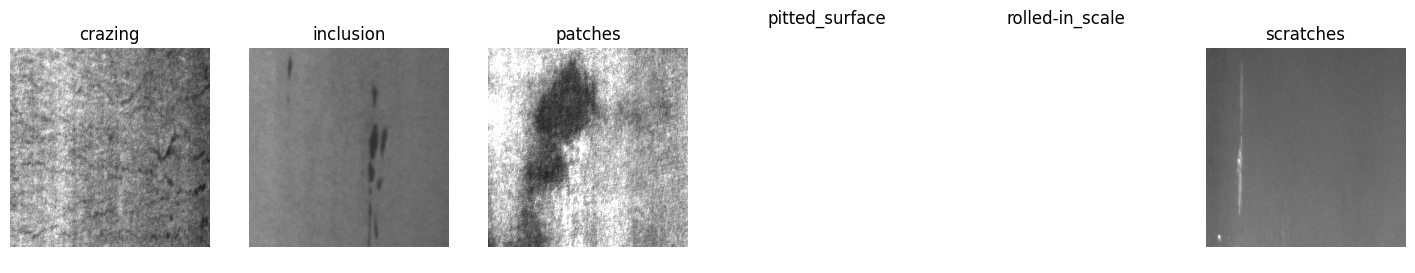

In [5]:
# One sample per defect class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 3))
for ax, cls in zip(axes, CLASS_NAMES):
    matches = [p for p, c in labelled if c == cls]
    if matches:
        ax.imshow(cv2.cvtColor(cv2.imread(matches[0]), cv2.COLOR_BGR2RGB))
    ax.set_title(cls)
    ax.axis('off')
plt.show()

In [6]:
NORMAL_SOURCE = None  # e.g. '/content/normal_images'
IMG_SIZE = (128, 128)

def load_gray(p, size=IMG_SIZE):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

images, labels = [], []
for p, c in labelled:
    im = load_gray(p)
    if im is not None:
        images.append(im)
        labels.append(c)

if NORMAL_SOURCE and os.path.isdir(NORMAL_SOURCE):
    for p in glob.glob(os.path.join(NORMAL_SOURCE, '**', '*'), recursive=True):
        if p.lower().endswith(IMG_EXTS):
            im = load_gray(p)
            if im is not None:
                images.append(im)
                labels.append('normal')

X_imgs = np.array(images)
y = np.array(labels)
HAS_NORMAL = 'normal' in set(y)
print('Image array:', X_imgs.shape)
print('Class counts:', Counter(y))
if not HAS_NORMAL:
    print('No defect-free class. Running six-class defect classification; set NORMAL_SOURCE for the binary task.')

Image array: (1200, 128, 128)
Class counts: Counter({np.str_('crazing'): 300, np.str_('inclusion'): 300, np.str_('patches'): 300, np.str_('scratches'): 300})
No defect-free class. Running six-class defect classification; set NORMAL_SOURCE for the binary task.


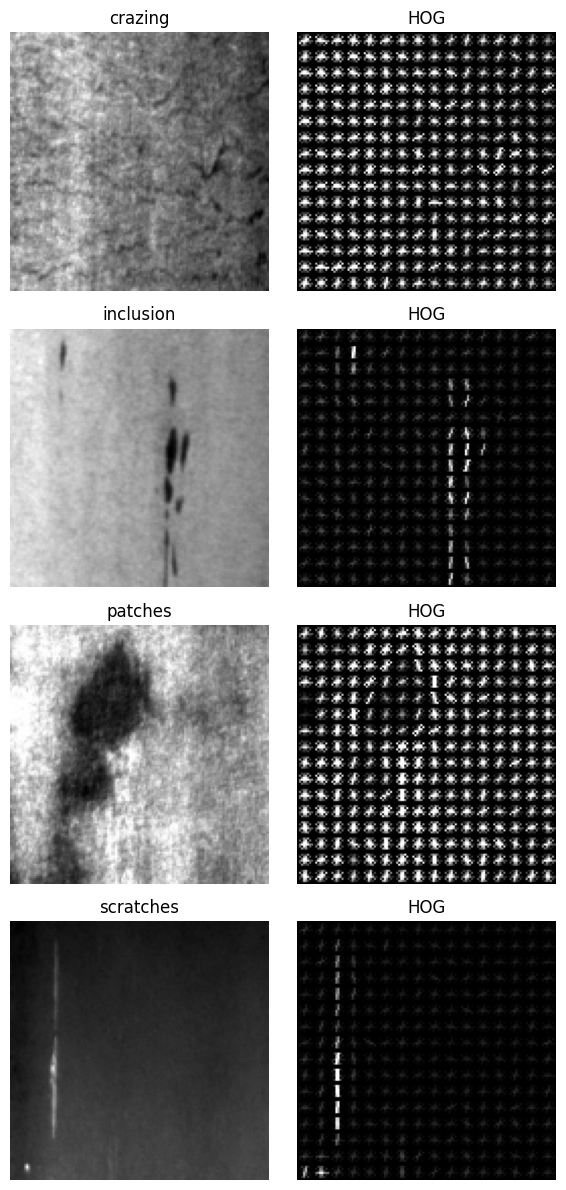

In [7]:
from skimage.feature import hog
from skimage import exposure

CELL, ORIENT, BLOCK = 8, 9, 2

def extract_hog(images, cell=CELL, orient=ORIENT, block=BLOCK):
    return np.array([hog(im, orientations=orient,
                         pixels_per_cell=(cell, cell),
                         cells_per_block=(block, block),
                         block_norm='L2-Hys', feature_vector=True)
                     for im in images])

# Representative image per class, with its HOG visualization
rep_idx = [int(np.where(y == cls)[0][0]) for cls in np.unique(y)]
fig, axes = plt.subplots(len(rep_idx), 2, figsize=(6, 3 * len(rep_idx)))
for row, i in enumerate(rep_idx):
    _, hog_img = hog(X_imgs[i], orientations=ORIENT, pixels_per_cell=(CELL, CELL),
                     cells_per_block=(BLOCK, BLOCK), visualize=True)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    axes[row, 0].imshow(X_imgs[i], cmap='gray'); axes[row, 0].set_title(y[i]); axes[row, 0].axis('off')
    axes[row, 1].imshow(hog_img, cmap='gray'); axes[row, 1].set_title('HOG'); axes[row, 1].axis('off')
plt.tight_layout(); plt.show()

## 6. Stratified train/test split

In [8]:
from sklearn.model_selection import train_test_split

Xtr_i, Xte_i, ytr, yte = train_test_split(X_imgs, y, test_size=0.25, stratify=y, random_state=42)
print('Train:', Xtr_i.shape, ' Test:', Xte_i.shape)

Train: (900, 128, 128)  Test: (300, 128, 128)


## 7. Train HOG + SVM and HOG + Random Forest

Metrics are macro-averaged across classes. When a defect-free class exists, binary Defective / Non-Defective metrics are added.

In [9]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

def binary_scores(y_true, y_pred):
    bt = (np.asarray(y_true) != 'normal').astype(int)
    bp = (np.asarray(y_pred) != 'normal').astype(int)
    p, r, f, _ = precision_recall_fscore_support(bt, bp, average='binary', zero_division=0)
    return {'Binary Accuracy': accuracy_score(bt, bp), 'Binary Precision': p,
            'Binary Recall': r, 'Binary F1': f}

def score(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    out = {'Accuracy': accuracy_score(y_true, y_pred), 'Macro Precision': p,
           'Macro Recall': r, 'Macro F1': f}
    if HAS_NORMAL:
        out.update(binary_scores(y_true, y_pred))
    return out

def build_models():
    return {
        'HOG + SVM (RBF)': make_pipeline(StandardScaler(),
                                         SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
        'HOG + Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    }

Xtr = extract_hog(Xtr_i)
Xte = extract_hog(Xte_i)
print('HOG feature length:', Xtr.shape[1])

results = {}
for name, model in build_models().items():
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    results[name] = {'model': model, 'pred': y_pred, 'metrics': score(yte, y_pred)}

summary = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T.round(4)
summary

HOG feature length: 8100


,Accuracy,Macro Precision,Macro Recall,Macro F1
HOG + SVM (RBF),0.9200,0.9222,0.9200,0.9194
HOG + Random Forest,0.8567,0.8661,0.8567,0.8549


## 8. Confusion matrix and classification report

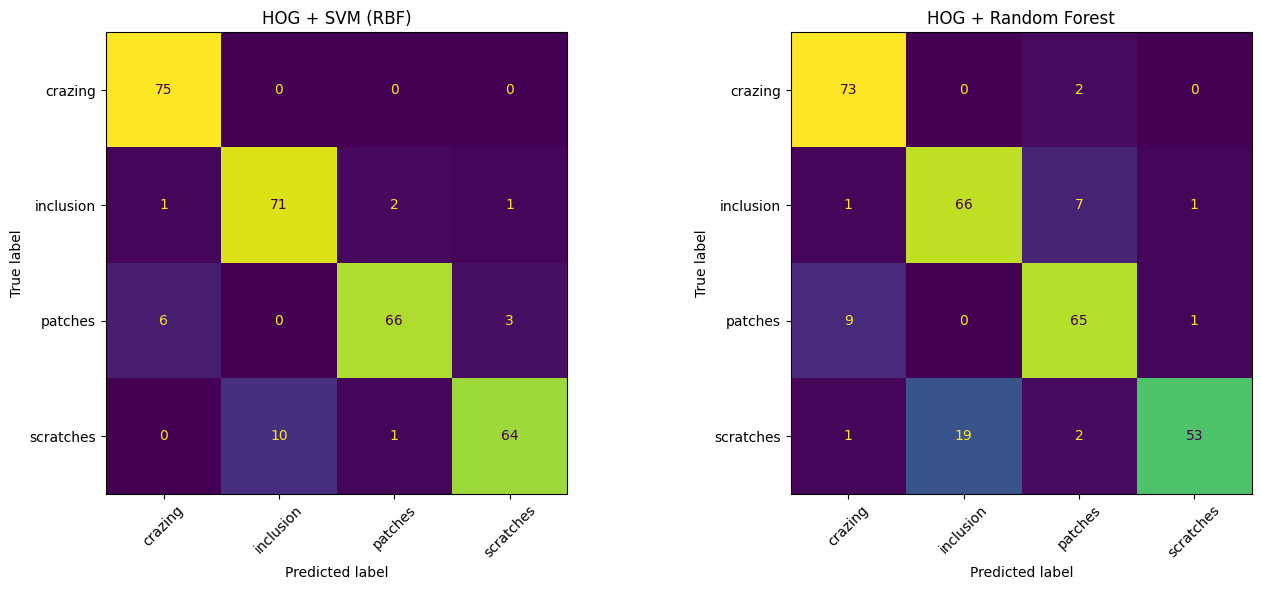

HOG + SVM (RBF)
              precision    recall  f1-score   support

     crazing       0.91      1.00      0.96        75
   inclusion       0.88      0.95      0.91        75
     patches       0.96      0.88      0.92        75
   scratches       0.94      0.85      0.90        75

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

HOG + Random Forest
              precision    recall  f1-score   support

     crazing       0.87      0.97      0.92        75
   inclusion       0.78      0.88      0.82        75
     patches       0.86      0.87      0.86        75
   scratches       0.96      0.71      0.82        75

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.85       300
weighted avg       0.87      0.86      0.85       300



In [10]:
labels_order = sorted(set(y))
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 6))
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    cm = confusion_matrix(yte, r['pred'], labels=labels_order)
    ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name)
plt.tight_layout(); plt.show()

for name, r in results.items():
    print('=' * 70)
    print(name)
    print(classification_report(yte, r['pred'], labels=labels_order, zero_division=0))

## 9. HOG parameter sweep: cell size and orientations

Cell sizes 4, 8, 16 and orientations 6, 9, 12, with an SVM retrained for each combination on the same split. Smaller cells give longer feature vectors and take longer to compute.

In [11]:
sweep_rows = []
for cell in [4, 8, 16]:
    for orient in [6, 9, 12]:
        Ftr = extract_hog(Xtr_i, cell, orient)
        Fte = extract_hog(Xte_i, cell, orient)
        clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10, gamma='scale'))
        clf.fit(Ftr, ytr)
        m = score(yte, clf.predict(Fte))
        sweep_rows.append({'cell': cell, 'orient': orient, 'n_features': Ftr.shape[1], **m})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.round(4)

,cell,orient,n_features,Accuracy,Macro Precision,Macro Recall,Macro F1
0,4,6,23064,0.8733,0.8810,0.8733,0.8722
1,4,9,34596,0.8533,0.8627,0.8533,0.8512
2,4,12,46128,0.8767,0.8914,0.8767,0.8745
3,8,6,5400,0.9233,0.9257,0.9233,0.9226
4,8,9,8100,0.9200,0.9222,0.9200,0.9194
5,8,12,10800,0.9333,0.9387,0.9333,0.9330
6,16,6,1176,0.9433,0.9460,0.9433,0.9430
7,16,9,1764,0.9533,0.9552,0.9533,0.9532
8,16,12,2352,0.9567,0.9579,0.9567,0.9566


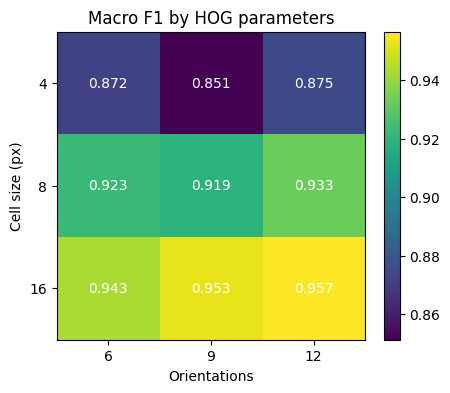

In [12]:
pivot = sweep_df.pivot(index='cell', columns='orient', values='Macro F1')
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot.values, cmap='viridis')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel('Orientations'); ax.set_ylabel('Cell size (px)')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', color='w')
ax.set_title('Macro F1 by HOG parameters')
plt.colorbar(im); plt.show()

## 10. Robustness analysis

The model is trained on clean images. Each perturbation is applied to the test set only. Changes are reported against the clean baseline.

In [13]:
rng = np.random.default_rng(42)

def brightness(im, f):
    return np.clip(im.astype(np.float32) * f, 0, 255).astype(np.uint8)

def gaussian_noise(im, sigma=20):
    return np.clip(im.astype(np.float32) + rng.normal(0, sigma, im.shape), 0, 255).astype(np.uint8)

def rotate(im, angle=15):
    h, w = im.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(im, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def blur(im, k=5):
    return cv2.GaussianBlur(im, (k, k), 0)

conditions = {
    'Clean': lambda x: x,
    'Brightness x0.6': lambda x: brightness(x, 0.6),
    'Brightness x1.4': lambda x: brightness(x, 1.4),
    'Gaussian noise (sigma=20)': lambda x: gaussian_noise(x, 20),
    'Rotation 15 deg': lambda x: rotate(x, 15),
    'Blur 5x5': lambda x: blur(x, 5),
}

best_name = max(results, key=lambda k: results[k]['metrics']['Macro F1'])
best = results[best_name]['model']
print('Robustness test on:', best_name)

rows = []
for cname, fn in conditions.items():
    Xc = extract_hog(np.array([fn(im) for im in Xte_i]))
    rows.append({'condition': cname, **score(yte, best.predict(Xc))})

rob = pd.DataFrame(rows)
base = rob.iloc[0]
rob['Δ Accuracy'] = rob['Accuracy'] - base['Accuracy']
rob['Δ Macro F1'] = rob['Macro F1'] - base['Macro F1']
rob[['condition', 'Accuracy', 'Macro F1', 'Δ Accuracy', 'Δ Macro F1']].round(4)

Robustness test on: HOG + SVM (RBF)


,condition,Accuracy,Macro F1,Δ Accuracy,Δ Macro F1
0,Clean,0.9200,0.9194,0.0000,0.0000
1,Brightness x0.6,0.9100,0.9100,-0.0100,-0.0093
2,Brightness x1.4,0.6667,0.6616,-0.2533,-0.2577
3,Gaussian noise (sigma=20),0.2567,0.1144,-0.6633,-0.8050
4,Rotation 15 deg,0.8667,0.8675,-0.0533,-0.0519
5,Blur 5x5,0.3033,0.1945,-0.6167,-0.7248


## 11. Industrial quality-control decision module

In [14]:
def inspect_product(image_path, model=best, cell=CELL, orient=ORIENT):
    im = load_gray(image_path)
    if im is None:
        raise ValueError('Could not read image: ' + image_path)
    proba = model.predict_proba(extract_hog([im], cell, orient))[0]
    classes = list(model.classes_)
    top = int(np.argmax(proba))
    pred_label = classes[top]

    if HAS_NORMAL:
        p_defect = 1 - proba[classes.index('normal')]
        is_defective = p_defect >= 0.5
        confidence = p_defect if is_defective else 1 - p_defect
    else:
        is_defective = True  # no defect-free class exists in NEU-DET
        confidence = proba[top]

    print('PRODUCT INSPECTION RESULT')
    print('Prediction:', 'DEFECTIVE' if is_defective else 'NON-DEFECTIVE')
    print(f'Confidence: {confidence * 100:.0f}%')
    print('Action:', 'REJECT PRODUCT' if is_defective else 'ACCEPT PRODUCT')
    if is_defective:
        print('Defect type:', pred_label)

if labelled:
    inspect_product(labelled[0][0])

PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100%
Action: REJECT PRODUCT
Defect type: crazing


## 12. Save the model

If you change `CELL` and `ORIENT` to the best values from section 9, rerun section 7 first so the saved model matches.

In [15]:
import joblib
joblib.dump({'model': best, 'cell': CELL, 'orient': ORIENT,
             'img_size': IMG_SIZE, 'has_normal': HAS_NORMAL}, 'hog_defect_model.joblib')
print('Saved hog_defect_model.joblib')

Saved hog_defect_model.joblib


## 13. Bonus: real-time webcam prototype (run locally, not in Colab)

Colab has no camera access. The cell below writes `realtime_inspect.py`, which you run on a laptop with a webcam after downloading `hog_defect_model.joblib`. For a real inspection line, point the camera at a steel surface under fixed lighting.

In [16]:
%%writefile realtime_inspect.py
import cv2
import joblib
from skimage.feature import hog

bundle = joblib.load('hog_defect_model.joblib')
model, cell, orient = bundle['model'], bundle['cell'], bundle['orient']

cap = cv2.VideoCapture(0)
while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, bundle['img_size'], interpolation=cv2.INTER_AREA)
    feat = hog(gray, orientations=orient, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)
    pred = model.predict([feat])[0]
    if bundle['has_normal'] and pred == 'normal':
        label, color = 'PASS', (0, 255, 0)
    else:
        label, color = 'DEFECTIVE', (0, 0, 255)
    cv2.putText(frame, label, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)
    cv2.imshow('Inspection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Writing realtime_inspect.py
